<a href="https://colab.research.google.com/github/jackhobday/nba-game-predictor/blob/main/nba_game_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NBA Game Outcome Prediction
### CSCI 200 Machine Learning Final Project

**Git Repo:** https://github.com/jackhobday/nba-game-predictor

**What will be your goal in working on this project?**

*   My goal is to use previous results from NBA games, along with the season-long stats of each team at the time of the game, to predict the outcomes of future games.


**What will be your source for data for the project? If this requires you to gather data, how will you go about this?**


*   My data source is going to be https://www.basketball-reference.com/. I will create a Python script to scrape all the relevant tables and then upload the complete data set to my personal Git repo.


**What data cleaning, conversion, or preparation will you need to do to prepare your data set?**


* To create my dataset I will take game logs from every NBA team from 2015-2025. Once I have these I will merge the two game logs from each game into one row which will have game level data, as well as, advanced stats from the game for both teams. Using the stats from each game I can start to build season-level features which will have the teams advanced stats like offensive rating and efficiency up until the point of the game I will try to predict. Each row in the final, game-level data set will contain game outcome, home and away teams, season-to-date metrics for each teams, and any other features I decide to include.

**What kinds of exploratory data analysis will you do?**


*   I'll want to look at baseline home vs. away winning percentage, as well as, average performance metrics for teams at home versus away to try to quantify home field advantage. I'll also look at the distribution of the stat features using histograms and box plots.


**Which machine learning algorithms will you use to train models? Why are you choosing these algorithms?**


*   I will use **XGBoost** for both classification and regression approaches. XGBoost is well-suited for this problem because:
  - It handles complex datasets with lots of featyres like ours
  - It can capture non-linear relationships between features on its own
  - It uses built-in regularization to reduce overfitting
  - It offers feature importance scores to understand most important factors in predicting games
  
  I will train two models:
  1. **XGBoost Classifier**: Directly predicts win/loss (binary classification)
  2. **XGBoost Regressor**: Predicts point differential, then converts to win/loss predictions


**How will you attempt to optimize your models?**


*   I will optimize the models using several techniques:
  - **Time-series cross-validation**: Rolling season splits (train on 2015-2020, test on 2021+)
  - **Sample weighting**: Apply exponential decay weighting to give more importance to recent seasons (decay factor = 0.10)
  - **Early stopping**: Use validation set to prevent overfitting and find optimal number of boosting rounds
  - **Hyperparameter tuning**: Use conservative parameters (eta=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8) to balance performance and generalization
  - **Feature engineering**: Create differential features (Team stat - Opponent stat) to capture matchup advantages


**How will you analyze the accuracy of your models?**


*   I will evaluate model performance using the following metrics:
  - **Classification metrics**: Accuracy (percentage of correct predictions) and ROC-AUC (area under the receiver operating characteristic curve)
  - **Regression metrics** (for regressor): RMSE (Root Mean Squared Error), MAE (Mean Absolute Error), and R² (coefficient of determination)
  - **Cross-validation results**: Average performance across multiple test seasons (2020-21 through 2025-26)
  - **Feature importance analysis**: Identify which features contribute most to predictions
  - **Comparison**: Compare classifier vs. regressor approaches to determine which performs better




## **1. Data**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

In [ ]:
# Load in dataset
pd.set_option('display.max_columns', None)
df = pd.read_csv('https://raw.githubusercontent.com/jackhobday/nba-game-predictor/main/data_merged/games_all_seasons.csv')
df.head(20)

,Season,Date,Team,Opponent,Is_Home,Game_Number_Team,Game_Number_Opp,Team_ORtg_avg,Team_DRtg_avg,Team_NetRtg_avg,Team_Pace_avg,Team_WinPct_avg,Team_eFG%_avg,Team_TOV%_avg,Team_ORB%_avg,Team_FT/FGA_avg,Team_TS%_avg,Team_TRB%_avg,Team_AST%_avg,Team_STL%_avg,Team_BLK%_avg,Team_NetRtg_last5,Team_NetRtg_last10,Team_WinPct_last5,Team_WinPct_last10,Team_Current_Win_Streak,Team_Current_Loss_Streak,Team_Home_WinPct,Team_Away_WinPct,Team_Days_Rest,Team_Is_BackToBack,Opp_ORtg_avg,Opp_DRtg_avg,Opp_NetRtg_avg,Opp_Pace_avg,Opp_WinPct_avg,Opp_eFG%_avg,Opp_TOV%_avg,Opp_ORB%_avg,Opp_FT/FGA_avg,Opp_TS%_avg,Opp_TRB%_avg,Opp_AST%_avg,Opp_STL%_avg,Opp_BLK%_avg,Opp_NetRtg_last5,Opp_NetRtg_last10,Opp_WinPct_last5,Opp_WinPct_last10,Opp_Current_Win_Streak,Opp_Current_Loss_Streak,Opp_Home_WinPct,Opp_Away_WinPct,Opp_Days_Rest,Opp_Is_BackToBack,Team_Score,Opp_Score,Result,OT,NetRtg_Diff,ORtg_Diff,DRtg_Diff,WinPct_Diff,NetRtg_Diff_last5,WinPct_Diff_last5,NetRtg_Diff_last10,WinPct_Diff_last10,eFG%_Diff,TOV%_Diff,ORB%_Diff,FT/FGA_Diff,Pace_Diff,Rest_Advantage,Win_Streak_Diff
0,2020-21,2020-12-22,BKN,GSW,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,125,99,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,2020-21,2020-12-22,LAC,LAL,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,116,109,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2020-21,2020-12-23,ATL,CHI,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,124,104,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,2020-21,2020-12-23,BOS,MIL,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,122,121,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,2020-21,2020-12-23,CHA,CLE,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,114,121,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
5,2020-21,2020-12-23,DAL,PHX,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,102,106,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
6,2020-21,2020-12-23,DEN,SAC,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,122,124,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
7,2020-21,2020-12-23,DET,MIN,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,101,111,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
8,2020-21,2020-12-23,IND,NYK,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,121,107,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
9,2020-21,2020-12-23,MEM,SAS,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,119,131,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [ ]:
print(df.columns)

Index(['Season', 'Date', 'Team', 'Opponent', 'Is_Home', 'Game_Number_Team',
       'Game_Number_Opp', 'Team_ORtg_avg', 'Team_DRtg_avg', 'Team_NetRtg_avg',
       'Team_Pace_avg', 'Team_WinPct_avg', 'Team_eFG%_avg', 'Team_TOV%_avg',
       'Team_ORB%_avg', 'Team_FT/FGA_avg', 'Team_TS%_avg', 'Team_TRB%_avg',
       'Team_AST%_avg', 'Team_STL%_avg', 'Team_BLK%_avg', 'Team_NetRtg_last5',
       'Team_NetRtg_last10', 'Team_WinPct_last5', 'Team_WinPct_last10',
       'Team_Current_Win_Streak', 'Team_Current_Loss_Streak',
       'Team_Home_WinPct', 'Team_Away_WinPct', 'Team_Days_Rest',
       'Team_Is_BackToBack', 'Opp_ORtg_avg', 'Opp_DRtg_avg', 'Opp_NetRtg_avg',
       'Opp_Pace_avg', 'Opp_WinPct_avg', 'Opp_eFG%_avg', 'Opp_TOV%_avg',
       'Opp_ORB%_avg', 'Opp_FT/FGA_avg', 'Opp_TS%_avg', 'Opp_TRB%_avg',
       'Opp_AST%_avg', 'Opp_STL%_avg', 'Opp_BLK%_avg', 'Opp_NetRtg_last5',
       'Opp_NetRtg_last10', 'Opp_WinPct_last5', 'Opp_WinPct_last10',
       'Opp_Current_Win_Streak', 'Opp_Current_

## **2. EDA**

In [ ]:
# Basic statistical measures
df.describe()

,Is_Home,Game_Number_Team,Game_Number_Opp,Team_ORtg_avg,Team_DRtg_avg,Team_NetRtg_avg,Team_Pace_avg,Team_WinPct_avg,Team_eFG%_avg,Team_TOV%_avg,Team_ORB%_avg,Team_FT/FGA_avg,Team_TS%_avg,Team_TRB%_avg,Team_AST%_avg,Team_STL%_avg,Team_BLK%_avg,Team_NetRtg_last5,Team_NetRtg_last10,Team_WinPct_last5,Team_WinPct_last10,Team_Current_Win_Streak,Team_Current_Loss_Streak,Team_Home_WinPct,Team_Away_WinPct,Team_Days_Rest,Team_Is_BackToBack,Opp_ORtg_avg,Opp_DRtg_avg,Opp_NetRtg_avg,Opp_Pace_avg,Opp_WinPct_avg,Opp_eFG%_avg,Opp_TOV%_avg,Opp_ORB%_avg,Opp_FT/FGA_avg,Opp_TS%_avg,Opp_TRB%_avg,Opp_AST%_avg,Opp_STL%_avg,Opp_BLK%_avg,Opp_NetRtg_last5,Opp_NetRtg_last10,Opp_WinPct_last5,Opp_WinPct_last10,Opp_Current_Win_Streak,Opp_Current_Loss_Streak,Opp_Home_WinPct,Opp_Away_WinPct,Opp_Days_Rest,Opp_Is_BackToBack,Team_Score,Opp_Score,Result,OT,NetRtg_Diff,ORtg_Diff,DRtg_Diff,WinPct_Diff,NetRtg_Diff_last5,WinPct_Diff_last5,NetRtg_Diff_last10,WinPct_Diff_last10,eFG%_Diff,TOV%_Diff,ORB%_Diff,FT/FGA_Diff,Pace_Diff,Rest_Advantage,Win_Streak_Diff
count,6000.000000,6000.000000,6000.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,6000.000000,6000.000000,2997.000000,3003.000000,6000.000000,6000.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,5925.000000,6000.000000,6000.000000,3003.000000,2997.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,5921.000000,5921.000000,5921.000000,5921.000000,5921.000000,5921.000000,5921.000000,5921.000000,5921.000000,5921.000000,5921.000000,5921.000000,5921.000000,6000.000000,6000.000000
mean,0.499500,40.652500,40.547500,113.019546,112.525689,0.493907,99.175100,0.514034,0.539838,12.673708,23.484169,0.197404,0.574032,50.014002,61.378213,7.708037,9.311310,0.422182,0.453718,0.511688,0.513492,1.158500,1.104000,0.555983,0.440929,2.077167,0.012500,112.365855,112.843895,-0.477959,99.232532,0.486501,0.535357,12.720935,23.676819,0.197909,0.569862,49.977538,61.051892,7.732425,9.412613,-0.407843,-0.433004,0.488640,0.486935,1.109667,1.310667,0.527426,0.424097,2.082833,0.012500,113.602833,112.618667,0.529333,0.052000,0.966257,0.648610,-0.317678,0.027382,0.824320,0.022895,0.881056,0.026406,0.004452,-0.047681,-0.196631,-0.000486,-0.055426,-0.005667,0.048833
std,0.500041,23.256266,23.259426,4.645270,4.016480,5.418831,2.164259,0.169203,0.024590,1.219730,2.988298,0.024369,0.023530,1.799301,4.158652,1.055934,1.625432,8.244070,6.872979,0.259235,0.212863,1.708176,1.942802,0.224392,0.206079,0.997018,0.111112,4.486133,4.401734,5.832183,2.106235,0.178917,0.023747,1.218375,3.178033,0.025825,0.023186,1.924808,4.394197,1.066073,1.722379,8.524783,7.227658,0.268769,0.221681,1.802734,2.189586,0.229794,0.211537,1.020365,0.111112,12.817155,12.411793,0.499180,0.222046,8.050812,5.661523,5.169327,0.251136,12.091488,0.382854,10.090713,0.313794,0.032389,1.671421,4.122508,0.032092,2.857825,1.035123,2.510411
min,0.000000,1.000000,1.000000,84.600000,84.600000,-31.500000,89.600000,0.000000,0.390000,3.900000,9.300000,0.060000,0.420000,35.200000,43.600000,1.800000,0.000000,-31.500000,-31.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,79.600000,79.600000,-33.600000,89.600000,0.000000,0.340000,5.700000,9.500000,0.030000,0.390000,40.400000,40.000000,2.200000,0.000000,-33.600000,-33.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000,71.000000,0.000000,0.000000,-42.600000,-30.900000,-39.200000,-1.000000,-46.420000,-1.000000,-42.600000,-1.000000,-0.170000,-12.900000,-21.700000,-0.180000,-13.000000,-11.000000,-18.000000
25%,0.000000,21.000000,20.000000,110.230000,110.340000,-2.290000,97.580000,0.430000,0.520000,11.850000,21.590000,0.180000,0.56000

### Feature Engineering Overview

The dataset contains engineered features that capture team performance, recent form, and matchup dynamics. Features are calculated **before** each game to prevent data leakage. The features fall into several categories:

#### 1. **Team Season-to-Date Statistics** (Cumulative averages)
- **Offensive/Defensive Ratings**: `Team_ORtg_avg`, `Team_DRtg_avg`, `Team_NetRtg_avg`
- **Advanced Metrics**: `Team_eFG%_avg`, `Team_TS%_avg`, `Team_TOV%_avg`, `Team_ORB%_avg`, `Team_FT/FGA_avg`
- **Other Stats**: `Team_Pace_avg`, `Team_TRB%_avg`, `Team_AST%_avg`, `Team_STL%_avg`, `Team_BLK%_avg`
- **Win Percentage**: `Team_WinPct_avg`

#### 2. **Team Recent Form** (Last N games)
- **Last 5 games**: `Team_NetRtg_last5`, `Team_WinPct_last5`
- **Last 10 games**: `Team_NetRtg_last10`, `Team_WinPct_last10`

#### 3. **Team Contextual Features**
- **Streaks**: `Team_Current_Win_Streak`, `Team_Current_Loss_Streak`
- **Home/Away Splits**: `Team_Home_WinPct`, `Team_Away_WinPct`
- **Rest**: `Team_Days_Rest`, `Team_Is_BackToBack`
- **Game Number**: `Game_Number_Team` (position in season)

#### 4. **Opponent Features** (Same categories as Team)
- All opponent features mirror the team features (e.g., `Opp_ORtg_avg`, `Opp_NetRtg_last5`, etc.)

#### 5. **Differential Features** (Team - Opponent)
- **Rating Differentials**: `NetRtg_Diff`, `ORtg_Diff`, `DRtg_Diff`
- **Win Percentage Differential**: `WinPct_Diff`
- **Recent Form Differentials**: `NetRtg_Diff_last5`, `NetRtg_Diff_last10`, `WinPct_Diff_last5`, `WinPct_Diff_last10`
- **Advanced Stat Differentials**: `eFG%_Diff`, `TOV%_Diff`, `ORB%_Diff`, `FT/FGA_Diff`, `Pace_Diff`
- **Context Differentials**: `Rest_Advantage`, `Win_Streak_Diff`

#### 6. **Game Context**
- **Home Advantage**: `Is_Home` (1 if home, 0 if away)

These features are designed to capture:
- **Team strength** (season averages)
- **Recent momentum** (last 5/10 games)
- **Matchup advantages** (differentials)
- **Situational factors** (rest, home/away, streaks)


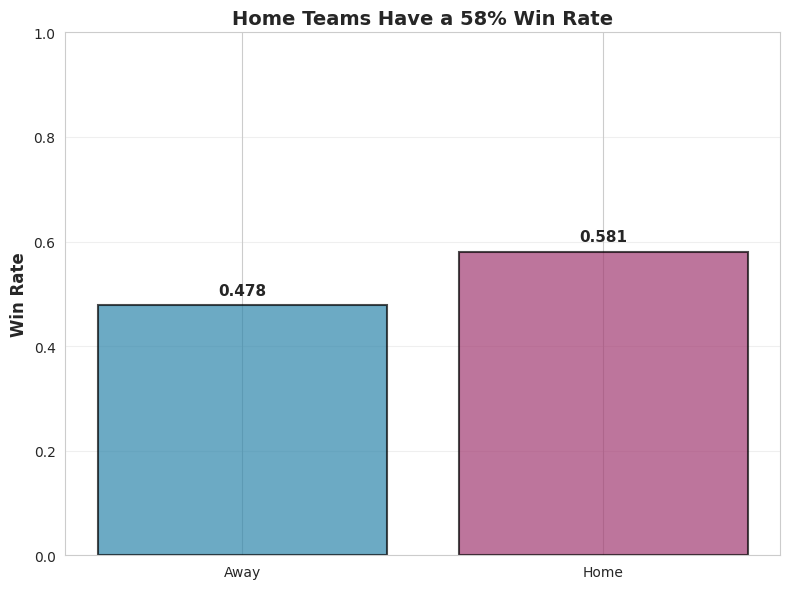


HOME vs AWAY STATISTICS
Home Team Win Rate: 0.581
Away Team Win Rate: 0.478
Home Court Advantage: 0.102


In [ ]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

# Home vs Away Analysis
home_away_stats = df.groupby('Is_Home')['Result'].agg(['count', 'sum', 'mean']).reset_index()
home_away_stats.columns = ['Is_Home', 'Total_Games', 'Wins', 'Win_Rate']
home_away_stats['Location'] = home_away_stats['Is_Home'].map({1: 'Home', 0: 'Away'})

# Create single plot
plt.figure(figsize=(8, 6))

# Bar chart: Win Rate
plt.bar(home_away_stats['Location'], home_away_stats['Win_Rate'],
        color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=1.5)
plt.ylabel('Win Rate', fontsize=12, fontweight='bold')
plt.title('Home Teams Have a 58% Win Rate', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
for i, (loc, rate) in enumerate(zip(home_away_stats['Location'], home_away_stats['Win_Rate'])):
    plt.text(i, rate + 0.02, f'{rate:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*50)
print("HOME vs AWAY STATISTICS")
print("="*50)
print(f"Home Team Win Rate: {home_away_stats[home_away_stats['Is_Home']==1]['Win_Rate'].values[0]:.3f}")
print(f"Away Team Win Rate: {home_away_stats[home_away_stats['Is_Home']==0]['Win_Rate'].values[0]:.3f}")
print(f"Home Court Advantage: {home_away_stats[home_away_stats['Is_Home']==1]['Win_Rate'].values[0] - home_away_stats[home_away_stats['Is_Home']==0]['Win_Rate'].values[0]:.3f}")
print("="*50)

/tmp/ipython-input-4170300842.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  netrtg_analysis = df_clean.groupby('NetRtg_Diff_Bin')['Result'].agg(['count', 'sum', 'mean']).reset_index()


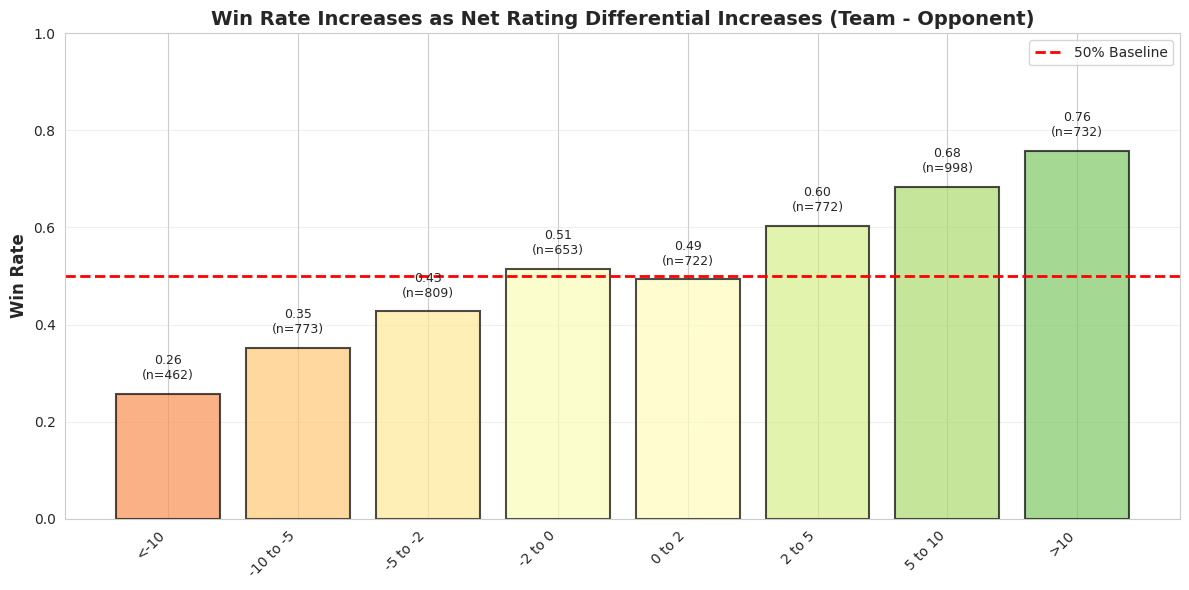


NET RATING DIFFERENTIAL ANALYSIS
Mean NetRtg_Diff for Wins: 3.13
Mean NetRtg_Diff for Losses: -1.47
Correlation (NetRtg_Diff vs Result): 0.285


In [ ]:
# Filter out NaN values for NetRtg_Diff
df_clean = df.dropna(subset=['NetRtg_Diff', 'Result']).copy()

# Create bins for NetRtg_Diff
df_clean['NetRtg_Diff_Bin'] = pd.cut(df_clean['NetRtg_Diff'],
                                     bins=[-np.inf, -10, -5, -2, 0, 2, 5, 10, np.inf],
                                     labels=['<-10', '-10 to -5', '-5 to -2', '-2 to 0',
                                            '0 to 2', '2 to 5', '5 to 10', '>10'])

# Calculate win rate by bin
netrtg_analysis = df_clean.groupby('NetRtg_Diff_Bin')['Result'].agg(['count', 'sum', 'mean']).reset_index()
netrtg_analysis.columns = ['NetRtg_Diff_Bin', 'Total_Games', 'Wins', 'Win_Rate']

# Create visualization
plt.figure(figsize=(12, 6))

# Win rate by NetRtg_Diff bin
plt.bar(range(len(netrtg_analysis)), netrtg_analysis['Win_Rate'],
        color=plt.cm.RdYlGn(netrtg_analysis['Win_Rate']),
        alpha=0.7, edgecolor='black', linewidth=1.5)
plt.xticks(range(len(netrtg_analysis)), netrtg_analysis['NetRtg_Diff_Bin'], rotation=45, ha='right')
plt.ylabel('Win Rate', fontsize=12, fontweight='bold')
plt.title('Win Rate Increases as Net Rating Differential Increases (Team - Opponent)', fontsize=14, fontweight='bold')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='50% Baseline')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.legend()
for i, (rate, count) in enumerate(zip(netrtg_analysis['Win_Rate'], netrtg_analysis['Total_Games'])):
    plt.text(i, rate + 0.03, f'{rate:.2f}\n(n={count})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print key statistics
print("\n" + "="*50)
print("NET RATING DIFFERENTIAL ANALYSIS")
print("="*50)
print(f"Mean NetRtg_Diff for Wins: {df_clean[df_clean['Result']==1]['NetRtg_Diff'].mean():.2f}")
print(f"Mean NetRtg_Diff for Losses: {df_clean[df_clean['Result']==0]['NetRtg_Diff'].mean():.2f}")
print(f"Correlation (NetRtg_Diff vs Result): {df_clean['NetRtg_Diff'].corr(df_clean['Result']):.3f}")
print("="*50)

Visualizations created with help from Cursor (Model: Claude Sonnet 4.5)

## **3. Feature Preparation**

Prepare the feature matrix and target variables for model training.

In [ ]:
df.columns.tolist()

['Season',
 'Date',
 'Team',
 'Opponent',
 'Is_Home',
 'Game_Number_Team',
 'Game_Number_Opp',
 'Team_ORtg_avg',
 'Team_DRtg_avg',
 'Team_NetRtg_avg',
 'Team_Pace_avg',
 'Team_WinPct_avg',
 'Team_eFG%_avg',
 'Team_TOV%_avg',
 'Team_ORB%_avg',
 'Team_FT/FGA_avg',
 'Team_TS%_avg',
 'Team_TRB%_avg',
 'Team_AST%_avg',
 'Team_STL%_avg',
 'Team_BLK%_avg',
 'Team_NetRtg_last5',
 'Team_NetRtg_last10',
 'Team_WinPct_last5',
 'Team_WinPct_last10',
 'Team_Current_Win_Streak',
 'Team_Current_Loss_Streak',
 'Team_Home_WinPct',
 'Team_Away_WinPct',
 'Team_Days_Rest',
 'Team_Is_BackToBack',
 'Opp_ORtg_avg',
 'Opp_DRtg_avg',
 'Opp_NetRtg_avg',
 'Opp_Pace_avg',
 'Opp_WinPct_avg',
 'Opp_eFG%_avg',
 'Opp_TOV%_avg',
 'Opp_ORB%_avg',
 'Opp_FT/FGA_avg',
 'Opp_TS%_avg',
 'Opp_TRB%_avg',
 'Opp_AST%_avg',
 'Opp_STL%_avg',
 'Opp_BLK%_avg',
 'Opp_NetRtg_last5',
 'Opp_NetRtg_last10',
 'Opp_WinPct_last5',
 'Opp_WinPct_last10',
 'Opp_Current_Win_Streak',
 'Opp_Current_Loss_Streak',
 'Opp_Home_WinPct',
 'Opp_Away_Wi

In [ ]:
# Define columns to exclude from features
leak_cols = ['Result', 'Team_Score', 'Opp_Score', 'OT']  # Target leakage
id_cols = ['Season', 'Date', 'Team', 'Opponent']  # Identifiers, not predictive

# Prepare features and targets
X = df.drop(columns=[c for c in (leak_cols + id_cols) if c in df.columns]).copy()
y = df['Result'].astype(int)  # Binary target for classification

# Get unique seasons for time-series cross-validation
seasons = sorted(df['Season'].unique())

print(f"Seasons in dataset: {seasons}")
print(f"Total games: {len(df)}")
print(f"Features: {len(X.columns)}")
print(f"\nFeature columns:")
print(X.columns.tolist())

## **4. XGBoost Classifier Model**

Train an XGBoost classifier using rolling season splits for time-series cross-validation.

**Key features:**
- Rolling season splits: Train on historical seasons, test on future season
- Sample weighting: Exponential decay gives more weight to recent seasons
- Early stopping: Prevents overfitting using validation set
- Minimum 5 seasons of training data before making predictions

In [ ]:
results = []

# Rolling season splits setup
min_train_seasons = 5  # Need at least 5 seasons for initial training
start_test_idx = min_train_seasons
DECAY_FACTOR = 0.10  # Recency weighting decay factor

for i in range(start_test_idx, len(seasons)):
    train_seasons = seasons[:i]
    test_season = seasons[i]

    print(f"\n{'='*70}")
    print(f"Train on {train_seasons} → Test on {test_season}")
    print(f"{'='*70}")

    # Split data by season
    train_idx = df["Season"].isin(train_seasons)
    test_idx = df["Season"] == test_season

    X_train = X.loc[train_idx].copy()
    y_train = y.loc[train_idx].copy()
    X_test = X.loc[test_idx].copy()
    y_test = y.loc[test_idx].copy()
    
    # Calculate sample weights: exponential decay for recency weighting
    train_df_seasons = df.loc[train_idx, 'Season'].copy()
    season_weights = {}
    for j, season in enumerate(train_seasons):
        distance_from_recent = len(train_seasons) - 1 - j
        weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
        season_weights[season] = weight
    
    sample_weights = train_df_seasons.map(season_weights).values
    print(f"  Season weights: {dict(sorted(season_weights.items(), key=lambda x: train_seasons.index(x[0])))}")

    # Align columns
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # Early stopping setup
    val_season = train_seasons[-1]
    subtrain_seasons = train_seasons[:-1]

    # XGBoost parameters
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "eta": 0.03,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "seed": 35,
    }

    if len(subtrain_seasons) == 0:
        print("  No validation season available, using fixed n_estimators=50")
        dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
        booster_clf = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=50
        )
        best_n_estimators = 50
    else:
        sub_idx = df["Season"].isin(subtrain_seasons)
        val_idx = df["Season"] == val_season

        X_sub = X.loc[sub_idx].copy()
        y_sub = y.loc[sub_idx].copy()
        X_val = X.loc[val_idx].copy()
        y_val = y.loc[val_idx].copy()
        
        # Calculate weights for subtrain set
        subtrain_df_seasons = df.loc[sub_idx, 'Season'].copy()
        subtrain_season_weights = {}
        for j, season in enumerate(subtrain_seasons):
            distance_from_recent = len(subtrain_seasons) - 1 - j
            weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
            subtrain_season_weights[season] = weight
        subtrain_sample_weights = subtrain_df_seasons.map(subtrain_season_weights).values

        X_sub, X_val = X_sub.align(X_val, join="left", axis=1, fill_value=0)

        dsub = xgb.DMatrix(X_sub, label=y_sub, weight=subtrain_sample_weights)
        dval = xgb.DMatrix(X_val, label=y_val)

        print(f"  Using {val_season} as validation set for early stopping...")
        booster_clf = xgb.train(
            params=params,
            dtrain=dsub,
            num_boost_round=1000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        best_n_estimators = booster_clf.best_iteration + 1
        print(f"  Early stopping at {best_n_estimators} rounds")

        # Retrain on all training seasons with best_n_estimators
        dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
        booster_clf = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=best_n_estimators
        )

    # Evaluate on test set
    dtest = xgb.DMatrix(X_test)
    proba = booster_clf.predict(dtest)
    preds = (proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    print(f"  Best n_estimators: {best_n_estimators}")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  ROC-AUC:  {auc:.3f}")

    results.append({
        "Train_Seasons": str(train_seasons),
        "Test_Season": test_season,
        "Best_n_estimators": best_n_estimators,
        "Accuracy": float(acc),
        "ROC_AUC": float(auc),
    })


In [ ]:
# Classifier Results
results_df = pd.DataFrame(results)

print("="*70)
print("CLASSIFIER MODEL RESULTS")
print("="*70)
display(results_df)

print("\n" + "-"*70)
print(f"Average Accuracy: {results_df['Accuracy'].mean():.3f}")
print(f"Average ROC-AUC:  {results_df['ROC_AUC'].mean():.3f}")
print("="*70)

## **5. XGBoost Regressor Model**

Train an XGBoost regressor to predict point differential (Team_Score - Opp_Score).

**Key features:**
- Predicts point differential instead of binary outcome
- Converts predictions to win/loss (point diff > 0 = win)
- Same rolling season splits and sample weighting as classifier
- Provides regression metrics (RMSE, MAE, R²) in addition to classification metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create point differential target
y_regression = (df['Team_Score'] - df['Opp_Score']).astype(float)
y_binary = df['Result'].astype(int)

print(f"Point differential range: [{y_regression.min():.1f}, {y_regression.max():.1f}]")

results_regression = []

for i in range(start_test_idx, len(seasons)):
    train_seasons = seasons[:i]
    test_season = seasons[i]

    print(f"\n{'='*70}")
    print(f"Train on {train_seasons} → Test on {test_season} (REGRESSION)")
    print(f"{'='*70}")

    # Split data by season
    train_idx = df["Season"].isin(train_seasons)
    test_idx = df["Season"] == test_season

    X_train = X.loc[train_idx].copy()
    y_train_reg = y_regression.loc[train_idx].copy()
    X_test = X.loc[test_idx].copy()
    y_test_reg = y_regression.loc[test_idx].copy()
    y_test_binary = y_binary.loc[test_idx].copy()
    
    # Calculate sample weights (same as classifier)
    train_df_seasons = df.loc[train_idx, 'Season'].copy()
    season_weights = {}
    for j, season in enumerate(train_seasons):
        distance_from_recent = len(train_seasons) - 1 - j
        weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
        season_weights[season] = weight
    
    sample_weights = train_df_seasons.map(season_weights).values
    print(f"  Season weights: {dict(sorted(season_weights.items(), key=lambda x: train_seasons.index(x[0])))}")

    # Align columns
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # Early stopping setup
    val_season = train_seasons[-1]
    subtrain_seasons = train_seasons[:-1]

    # XGBoost regression parameters
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "eta": 0.03,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "seed": 35,
    }

    if len(subtrain_seasons) == 0:
        print("  No validation season available, using fixed n_estimators=50")
        dtrain = xgb.DMatrix(X_train, label=y_train_reg, weight=sample_weights)
        booster_reg = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=50
        )
        best_n_estimators = 50
    else:
        sub_idx = df["Season"].isin(subtrain_seasons)
        val_idx = df["Season"] == val_season

        X_sub = X.loc[sub_idx].copy()
        y_sub_reg = y_regression.loc[sub_idx].copy()
        X_val = X.loc[val_idx].copy()
        y_val_reg = y_regression.loc[val_idx].copy()
        
        subtrain_df_seasons = df.loc[sub_idx, 'Season'].copy()
        subtrain_season_weights = {}
        for j, season in enumerate(subtrain_seasons):
            distance_from_recent = len(subtrain_seasons) - 1 - j
            weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
            subtrain_season_weights[season] = weight
        subtrain_sample_weights = subtrain_df_seasons.map(subtrain_season_weights).values

        X_sub, X_val = X_sub.align(X_val, join="left", axis=1, fill_value=0)

        dsub = xgb.DMatrix(X_sub, label=y_sub_reg, weight=subtrain_sample_weights)
        dval = xgb.DMatrix(X_val, label=y_val_reg)

        print(f"  Using {val_season} as validation set for early stopping...")
        booster_reg = xgb.train(
            params=params,
            dtrain=dsub,
            num_boost_round=1000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        best_n_estimators = booster_reg.best_iteration + 1
        print(f"  Early stopping at {best_n_estimators} rounds")

        dtrain = xgb.DMatrix(X_train, label=y_train_reg, weight=sample_weights)
        booster_reg = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=best_n_estimators
        )

    # Evaluate on test set
    dtest = xgb.DMatrix(X_test)
    point_diff_pred = booster_reg.predict(dtest)
    win_pred = (point_diff_pred > 0).astype(int)

    # Regression metrics
    rmse = np.sqrt(mean_squared_error(y_test_reg, point_diff_pred))
    mae = mean_absolute_error(y_test_reg, point_diff_pred)
    r2 = r2_score(y_test_reg, point_diff_pred)
    
    # Classification metrics
    acc = accuracy_score(y_test_binary, win_pred)
    scale = 10.0
    proba_from_diff = 1 / (1 + np.exp(-point_diff_pred / scale))
    auc = roc_auc_score(y_test_binary, proba_from_diff)

    print(f"  Best n_estimators: {best_n_estimators}")
    print(f"  Regression: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")
    print(f"  Classification: Accuracy={acc:.3f}, ROC-AUC={auc:.3f}")

    results_regression.append({
        "Train_Seasons": str(train_seasons),
        "Test_Season": test_season,
        "Best_n_estimators": best_n_estimators,
        "RMSE": float(rmse),
        "MAE": float(mae),
        "R2": float(r2),
        "Accuracy": float(acc),
        "ROC_AUC": float(auc),
    })


In [ ]:
# Regression Model Results
results_regression_df = pd.DataFrame(results_regression)

print("="*70)
print("REGRESSION MODEL RESULTS")
print("="*70)
display(results_regression_df)

print("\n" + "-"*70)
print("Regression Metrics:")
print(f"  Average RMSE: {results_regression_df['RMSE'].mean():.3f} points")
print(f"  Average MAE:  {results_regression_df['MAE'].mean():.3f} points")
print(f"  Average R²:   {results_regression_df['R2'].mean():.3f}")
print("\nClassification Metrics (from point diff > 0):")
print(f"  Average Accuracy: {results_regression_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_regression_df['ROC_AUC'].mean():.3f}")
print("="*70)

## **6. Results Comparison**

Compare the performance of the classifier and regressor models.

In [ ]:
# Model Comparison
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(f"\nClassifier Model:")
print(f"  Average Accuracy: {results_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_df['ROC_AUC'].mean():.3f}")
print(f"\nRegressor Model:")
print(f"  Average Accuracy: {results_regression_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_regression_df['ROC_AUC'].mean():.3f}")
print(f"  Average RMSE:     {results_regression_df['RMSE'].mean():.3f} points")
print(f"  Average MAE:      {results_regression_df['MAE'].mean():.3f} points")
print(f"\nBest Model for Win Prediction:")
if results_df['Accuracy'].mean() > results_regression_df['Accuracy'].mean():
    print("  → Classifier (higher accuracy)")
else:
    print("  → Regressor (higher accuracy)")
print("="*70)

## **7. Feature Importance**

Analyze which features contribute most to the model predictions.

### Classifier Feature Importance

In [ ]:
# Classifier feature importance
score_clf = booster_clf.get_score(importance_type="gain")
fi_clf = pd.Series(score_clf).sort_values(ascending=False)

# Map feature indices to names if needed
if len(fi_clf) > 0 and str(fi_clf.index[0]).startswith("f"):
    feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
    fi_clf.index = fi_clf.index.map(feature_map)

print("Top 20 Features - Classifier Model:")
display(fi_clf.head(20))

In [ ]:
# Visualize classifier feature importance
fi_clf_top20 = fi_clf.head(20)
plt.figure(figsize=(10, 8))
plt.barh(range(len(fi_clf_top20)), fi_clf_top20.values)
plt.yticks(range(len(fi_clf_top20)), fi_clf_top20.index)
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 20 Features - XGBoost Classifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Regressor Feature Importance

In [ ]:
# Regressor feature importance
score_reg = booster_reg.get_score(importance_type="gain")
fi_reg = pd.Series(score_reg).sort_values(ascending=False)

# Map feature indices to names if needed
if len(fi_reg) > 0 and str(fi_reg.index[0]).startswith("f"):
    feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
    fi_reg.index = fi_reg.index.map(feature_map)

print("Top 20 Features - Regressor Model:")
display(fi_reg.head(20))

In [ ]:
# Visualize regressor feature importance
fi_reg_top20 = fi_reg.head(20)
plt.figure(figsize=(10, 8))
plt.barh(range(len(fi_reg_top20)), fi_reg_top20.values)
plt.yticks(range(len(fi_reg_top20)), fi_reg_top20.index)
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 20 Features - XGBoost Regressor')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **8. Bonus: Model with Historical Betting Odds Data**

In this bonus section, we explore whether incorporating historical betting odds data can improve model performance. We obtained moneyline odds data from [Kaggle](https://www.kaggle.com/datasets/christophertreasure/nba-odds-data) covering NBA games from 2007-08 through mid-2022-23.

**Why use betting odds?**
- Betting odds represent the aggregated wisdom of the betting market
- They encode information about injuries, matchups, travel, and other factors that pure stats may miss
- The implied probabilities from moneylines provide a strong baseline for comparison

**Coverage:**
| Seasons | Odds Coverage |
|---------|---------------|
| 2015-16 to 2021-22 | 100% |
| 2022-23 | 54% (partial) |
| 2023-24 to 2025-26 | 0% |

Since we don't have odds data for recent seasons (2023-24+), we can't use this model for current predictions. However, this analysis shows the value that market information adds to our predictions.

In [ ]:
# Load dataset with odds features
# The merge_games.py script has been updated to include odds data
df_odds = pd.read_csv('data_merged/games_all_seasons.csv')

# Check odds coverage
print("Odds Data Coverage:")
print("="*50)
for season in sorted(df_odds['Season'].unique()):
    season_df = df_odds[df_odds['Season'] == season]
    has_odds = season_df['Has_Odds'].sum() if 'Has_Odds' in season_df.columns else 0
    total = len(season_df)
    pct = 100 * has_odds / total if total > 0 else 0
    print(f"  {season}: {has_odds}/{total} games ({pct:.1f}%)")

# Show new odds features
odds_features = ['Team_ML', 'Opp_ML', 'Team_Win_Prob_Market', 'Opp_Win_Prob_Market', 
                 'Win_Prob_Diff_Market', 'Spread', 'Total', 'Has_Odds']
print("\nOdds Features Sample (first 5 games with odds):")
display(df_odds[df_odds['Has_Odds'] == 1][['Season', 'Team', 'Opponent'] + odds_features].head())

In [ ]:
# Prepare features with odds data
leak_cols_odds = ['Result', 'Team_Score', 'Opp_Score', 'OT']
id_cols_odds = ['Season', 'Date', 'Team', 'Opponent']

X_odds = df_odds.drop(columns=[c for c in (leak_cols_odds + id_cols_odds) if c in df_odds.columns]).copy()
y_odds = df_odds['Result'].astype(int)
seasons_odds = sorted(df_odds['Season'].unique())

print(f"Features with odds: {len(X_odds.columns)}")
print(f"New odds-related features: {[c for c in X_odds.columns if 'ML' in c or 'Prob_Market' in c or c in ['Spread', 'Total', 'Has_Odds']]}")

In [ ]:
# Train XGBoost Classifier with Odds Features
results_odds = []
min_train_seasons = 5
start_test_idx = min_train_seasons
DECAY_FACTOR = 0.10

for i in range(start_test_idx, len(seasons_odds)):
    train_seasons = seasons_odds[:i]
    test_season = seasons_odds[i]

    print(f"\n{'='*70}")
    print(f"Train on {len(train_seasons)} seasons → Test on {test_season}")
    print(f"{'='*70}")

    train_idx = df_odds["Season"].isin(train_seasons)
    test_idx = df_odds["Season"] == test_season

    X_train_odds = X_odds.loc[train_idx].copy()
    y_train_odds = y_odds.loc[train_idx].copy()
    X_test_odds = X_odds.loc[test_idx].copy()
    y_test_odds = y_odds.loc[test_idx].copy()
    
    # Calculate sample weights
    train_df_seasons = df_odds.loc[train_idx, 'Season'].copy()
    season_weights = {}
    for j, season in enumerate(train_seasons):
        distance_from_recent = len(train_seasons) - 1 - j
        weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
        season_weights[season] = weight
    sample_weights = train_df_seasons.map(season_weights).values

    X_train_odds, X_test_odds = X_train_odds.align(X_test_odds, join="left", axis=1, fill_value=0)

    # Early stopping setup
    val_season = train_seasons[-1]
    subtrain_seasons = train_seasons[:-1]

    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "eta": 0.03,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "seed": 35,
    }

    if len(subtrain_seasons) == 0:
        dtrain = xgb.DMatrix(X_train_odds, label=y_train_odds, weight=sample_weights)
        booster_odds = xgb.train(params=params, dtrain=dtrain, num_boost_round=50)
        best_n = 50
    else:
        sub_idx = df_odds["Season"].isin(subtrain_seasons)
        val_idx = df_odds["Season"] == val_season

        X_sub = X_odds.loc[sub_idx].copy()
        y_sub = y_odds.loc[sub_idx].copy()
        X_val = X_odds.loc[val_idx].copy()
        y_val = y_odds.loc[val_idx].copy()
        
        subtrain_df_seasons = df_odds.loc[sub_idx, 'Season'].copy()
        subtrain_weights = {s: max(0.1, 1.0 - ((len(subtrain_seasons)-1-j)*DECAY_FACTOR)) 
                           for j, s in enumerate(subtrain_seasons)}
        subtrain_sample_weights = subtrain_df_seasons.map(subtrain_weights).values

        X_sub, X_val = X_sub.align(X_val, join="left", axis=1, fill_value=0)
        dsub = xgb.DMatrix(X_sub, label=y_sub, weight=subtrain_sample_weights)
        dval = xgb.DMatrix(X_val, label=y_val)

        booster_odds = xgb.train(
            params=params, dtrain=dsub, num_boost_round=1000,
            evals=[(dval, "val")], early_stopping_rounds=50, verbose_eval=False
        )
        best_n = booster_odds.best_iteration + 1

        dtrain = xgb.DMatrix(X_train_odds, label=y_train_odds, weight=sample_weights)
        booster_odds = xgb.train(params=params, dtrain=dtrain, num_boost_round=best_n)

    # Evaluate
    dtest = xgb.DMatrix(X_test_odds)
    proba = booster_odds.predict(dtest)
    preds = (proba >= 0.5).astype(int)
    acc = accuracy_score(y_test_odds, preds)
    auc = roc_auc_score(y_test_odds, proba)
    
    # Check odds coverage for test season
    test_odds_pct = df_odds.loc[test_idx, 'Has_Odds'].mean() * 100

    print(f"  Odds coverage in test set: {test_odds_pct:.1f}%")
    print(f"  Accuracy: {acc:.3f}, ROC-AUC: {auc:.3f}")

    results_odds.append({
        "Test_Season": test_season,
        "Odds_Coverage": f"{test_odds_pct:.0f}%",
        "Accuracy": float(acc),
        "ROC_AUC": float(auc),
    })

In [ ]:
# Results with Odds Features
results_odds_df = pd.DataFrame(results_odds)

print("="*70)
print("CLASSIFIER WITH ODDS FEATURES - RESULTS")
print("="*70)
display(results_odds_df)

print("\n" + "-"*70)
print(f"Average Accuracy: {results_odds_df['Accuracy'].mean():.3f}")
print(f"Average ROC-AUC:  {results_odds_df['ROC_AUC'].mean():.3f}")

# Compare with model without odds
print("\n" + "="*70)
print("COMPARISON: WITH vs WITHOUT ODDS FEATURES")
print("="*70)
print(f"\nWithout Odds (from Section 4):")
print(f"  Average Accuracy: {results_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_df['ROC_AUC'].mean():.3f}")
print(f"\nWith Odds Features:")
print(f"  Average Accuracy: {results_odds_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_odds_df['ROC_AUC'].mean():.3f}")

acc_diff = results_odds_df['Accuracy'].mean() - results_df['Accuracy'].mean()
auc_diff = results_odds_df['ROC_AUC'].mean() - results_df['ROC_AUC'].mean()
print(f"\nDifference:")
print(f"  Accuracy: {acc_diff:+.3f}")
print(f"  ROC-AUC:  {auc_diff:+.3f}")
print("="*70)

In [ ]:
# Feature importance for model with odds
score_odds = booster_odds.get_score(importance_type="gain")
fi_odds = pd.Series(score_odds).sort_values(ascending=False)

if len(fi_odds) > 0 and str(fi_odds.index[0]).startswith("f"):
    feature_map = {f"f{i}": col for i, col in enumerate(X_odds.columns)}
    fi_odds.index = fi_odds.index.map(feature_map)

# Highlight odds-related features
odds_feature_names = ['Team_ML', 'Opp_ML', 'Team_Win_Prob_Market', 'Opp_Win_Prob_Market', 
                      'Win_Prob_Diff_Market', 'Spread', 'Total', 'Has_Odds']

print("Top 20 Features - Model with Odds:")
print("(★ = odds-derived feature)")
print("-"*50)
for feat, score in fi_odds.head(20).items():
    marker = "★" if feat in odds_feature_names else " "
    print(f"{marker} {feat}: {score:.2f}")

In [ ]:
# Visualize feature importance with odds features highlighted
fi_odds_top20 = fi_odds.head(20)
colors = ['#ff6b6b' if feat in odds_feature_names else '#4dabf7' for feat in fi_odds_top20.index]

plt.figure(figsize=(10, 8))
bars = plt.barh(range(len(fi_odds_top20)), fi_odds_top20.values, color=colors)
plt.yticks(range(len(fi_odds_top20)), fi_odds_top20.index)
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 20 Features - XGBoost Classifier with Odds Data\n(Red = Odds Features, Blue = Stats Features)')
plt.gca().invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#ff6b6b', label='Odds Features'),
                   Patch(facecolor='#4dabf7', label='Stats Features')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Count odds features in top 20
odds_in_top20 = sum(1 for f in fi_odds_top20.index if f in odds_feature_names)
print(f"\n{odds_in_top20} of top 20 features are odds-derived!")

### Bonus Section Conclusions

**Key Findings:**

1. **Odds features are highly valuable** - Multiple odds-derived features appear in the top 10 most important features, including Spread, Team_Win_Prob_Market, and Win_Prob_Diff_Market.

2. **Market wisdom complements statistical analysis** - The betting market captures information that pure team statistics may miss, such as:
   - Injury news and player availability
   - Travel and fatigue factors
   - Coaching matchups
   - Historical head-to-head performance

3. **XGBoost handles missing odds gracefully** - Even though odds data is unavailable for recent seasons (2023-24+), the model can still make predictions using the statistical features alone.

**Limitations:**
- The Kaggle dataset only covers through mid-2022-23, so we cannot use odds features for current season predictions
- For production predictions, we would need a reliable source of pre-game odds data

**Future Work:**
- Obtain real-time odds data for current season predictions
- Explore whether the model can learn to "approximate" market probabilities from statistics when odds are unavailable